In [10]:
!pip install stochastic


In [2]:

from files.functions import *

# optionally import stochastic if you intend to use it
try:
    from stochastic.processes.continuous import GeometricBrownianMotion
except ImportError:
    GeometricBrownianMotion = None

In [3]:
data = pd.read_csv(fullDataPath('BTC'))


In [4]:
# Convert time to datetime if it's not already
data['time'] = pd.to_datetime(data['time'], errors='coerce')
data = data.dropna(subset=['time'])

# Extract date component
data['date'] = data['time'].dt.date

# Group by date and aggregate values (one row per day)
# Hard coded change later
daily_data = (
    data
    .groupby('date')
    .agg(
        close=('close', 'last'),  # Take the last close price of the day
        avg_sentiment=('score', 'mean'),  # Average sentiment for the day
        tweet_count=('score', 'count'),   # Number of observations per day
        volume=('volume', 'last'),          # Total volume for the day
        BB_Lower=('BB_Lower', 'last'),  # Last value of BB lower band
        BB_Middle=('BB_Middle', 'last'),  # Last value of BB middle band
        BB_Upper=('BB_Upper', 'last'),  # Last value of BB upper band
        SMA_50=('SMA_50', 'last'),  # Last value of SMA 50
        Volume_MA_20=('Volume_MA_20', 'last'),  # Last value of Volume MA 20
        value=('value', 'last'),
        value_classification=('value_classification', 'last'),
        OBV=('OBV', 'last')
    )
    .reset_index()
)

# Convert date back to datetime format if needed
daily_data['time'] = pd.to_datetime(daily_data['date'])
daily_data = daily_data.drop('date', axis=1)

# Sort by time
daily_data = daily_data.sort_values('time')
daily_data.set_index('time', inplace=True)
daily_data['gradient'] = daily_data['close'].diff().fillna(0.0)
daily_data

,close,avg_sentiment,tweet_count,volume,BB_Lower,BB_Middle,BB_Upper,SMA_50,Volume_MA_20,value,value_classification,OBV,gradient
time,,,,,,,,,,,,,
2024-06-22,64235.01,0.000000,1,2324.215004,54851.402602,59917.7460,64984.089398,61935.6492,11424.656837,51.0,Neutral,-265005.295319,0.00
2024-06-23,63171.43,0.000000,1,2054.790924,54892.720753,59601.4470,64310.173247,61825.3988,11834.276287,51.0,Neutral,-267329.510323,-1063.58
2024-06-24,60263.00,0.000000,1,21418.045946,55004.682110,59404.1045,63803.526890,61749.1458,11944.292014,49.0,Neutral,-269384.301246,-2908.43
2024-06-25,61789.71,0.000000,1,15201.582477,55002.870135,59431.3755,63859.880865,61755.9496,11180.008418,44.0,Neutral,-247966.255300,1526.71
2024-06-26,60816.68,0.000000,1,11392.798350,54648.273685,59579.7480,64511.222315,61693.9678,11450.015988,46.0,Neutral,-263167.837777,-973.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17,104590.44,-14.691853,27,7688.118620,101196.959288,105613.7385,110030.517712,104758.8508,0.000000,53.0,Neutral,4554.432367,-2262.94
2025-06-18,104915.60,-3.024723,41,4918.143827,101196.959288,105613.7385,110030.517712,104758.8508,0.000000,48.0,Neutral,12242.550987,325.16
2025-06-19,104671.90,0.042884,47,2276.969285,101196.959288,105613.7385,110030.517712,104758.8508,0.000000,48.0,Neutral,7324.407160,-243.70


In [5]:
daily_data['log_ret'] = np.log(daily_data['close'] / daily_data['close'].shift(1))
daily_data = daily_data.dropna(subset=['log_ret'])

# Annualize drift (mu) and volatility (sigma)
steps_per_year = 365
mu_hat    = daily_data['log_ret'].mean() * steps_per_year
sigma_hat = daily_data['log_ret'].std(ddof=0) * np.sqrt(steps_per_year)

print(f"Estimated annual drift (mu): {mu_hat:.4f}")
print(f"Estimated annual vol   (sigma): {sigma_hat:.4f}")


Estimated annual drift (mu): 0.4664
Estimated annual vol   (sigma): 0.4947


In [7]:
def gbm_paths_numpy(S0, mu, sigma, T=1.0, steps_per_year=365, n_paths=5, seed=None):
    """
    Simulate GBM sample paths with explicit Euler scheme.
    Returns a DataFrame of shape (N+1) x n_paths, indexed by pandas dates.
    """
    if seed is not None:
        np.random.seed(seed)

    dt = 1 / steps_per_year
    N  = int(T * steps_per_year)
    # generate random shocks
    Z = np.random.normal(size=(N, n_paths))
    # log-return increments
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    increments = np.vstack([np.zeros(n_paths), increments])
    # price paths
    S = S0 * np.exp(np.cumsum(increments, axis=0))

    # build date index starting at today
    start = daily_data.index[-1]  # last date in your historical series
    dates = pd.date_range(start=start, periods=N+1, freq='D')
    return pd.DataFrame(S, index=dates)

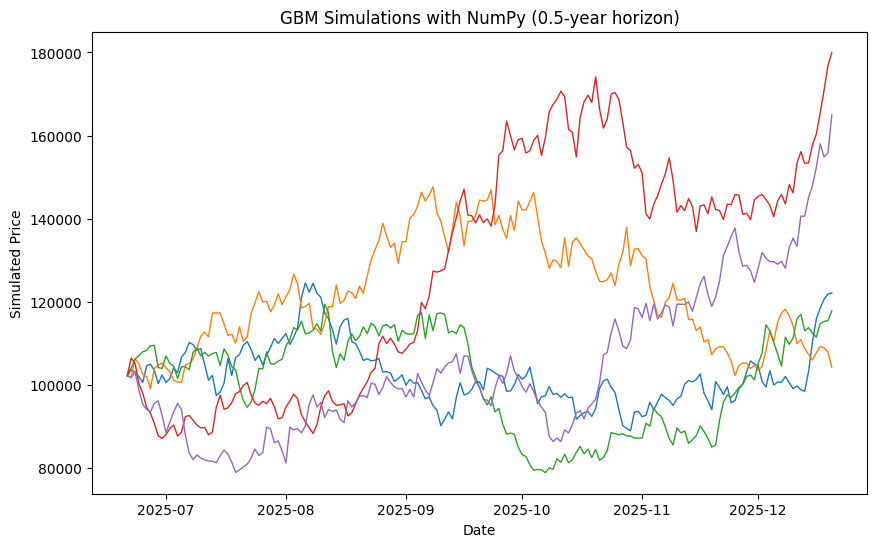

In [8]:
S0 = daily_data['close'].iloc[-1]  # starting price = last close
paths_np = gbm_paths_numpy(S0, mu_hat, sigma_hat, T=0.5, steps_per_year=365, n_paths=5, seed=42)

plt.figure(figsize=(10,6))
for col in paths_np.columns:
    plt.plot(paths_np.index, paths_np[col], linewidth=1)
plt.title('GBM Simulations with NumPy (0.5-year horizon)')
plt.xlabel('Date')
plt.ylabel('Simulated Price')
plt.grid(False)
plt.show()

In [11]:
if GeometricBrownianMotion is not None:
    # Instantiate GBM process with unit initial value implied
    gbm = GeometricBrownianMotion(drift=mu_hat, volatility=sigma_hat)
    # Number of steps for a 0.5-year horizon (daily samples)
    num_steps = int(365 * 0.5)
    # Sample GBM: returns unit-price array of length num_steps+1
    S_unit = gbm.sample(num_steps)
    # Create time array from 0 to 0.5 years
    t = np.linspace(0, 0.5, len(S_unit))
    # Scale by the last observed price
    S = S0 * S_unit

    plt.figure(figsize=(10,6))
    plt.plot(t, S, color='purple', linewidth=2)
    plt.title('GBM Simulation with `stochastic` (0.5-year)')
    plt.xlabel('Time (years)')
    plt.ylabel('Simulated Price')
    plt.grid(False)
    plt.show()
else:
    print("`stochastic` package not installed. Install via `pip install stochastic` to use this cell.")

`stochastic` package not installed. Install via `pip install stochastic` to use this cell.


In [13]:
weekly_summary = []
dates = paths_np.index
n = len(dates)
for i in range(0, n, 7):
    block = paths_np.iloc[i:i+7]
    if block.empty:
        continue
    start = block.index[0]
    end   = block.index[-1]
    # Predicted prices at block start and end across all paths
    preds_start = block.iloc[0].values
    preds_end   = block.iloc[-1].values
    # Compute statistics for end-of-week predictions
    mean_pred = preds_end.mean()
    lower_ci  = np.percentile(preds_end, 2.5)
    upper_ci  = np.percentile(preds_end, 97.5)
    # Determine label by comparing end CI to start-of-week predicted price
    start_pred = preds_start.mean()
    if lower_ci > start_pred:
        label = 'Bullish'
    elif upper_ci < start_pred:
        label = 'Bearish'
    else:
        label = 'Neutral'
    weekly_summary.append({
        'start':         start,
        'end':           end,
        'start_pred':    start_pred,
        'mean_end_pred': mean_pred,
        'lower_ci':      lower_ci,
        'upper_ci':      upper_ci,
        'label':         label
    })
# Build DataFrame and display
weekly_df = pd.DataFrame(weekly_summary).set_index('start')
weekly_df


,end,start_pred,mean_end_pred,lower_ci,upper_ci,label
start,,,,,,
2025-06-21,2025-06-27,102272.720000,100091.174835,93261.478000,109044.176207,Neutral
2025-06-28,2025-07-04,100726.944901,97746.003939,88532.887232,102829.321131,Neutral
2025-07-05,2025-07-11,98921.179614,99464.151963,82814.577391,112259.077569,Neutral
2025-07-12,2025-07-18,97929.055036,99258.299890,82921.622541,111464.514712,Neutral
2025-07-19,2025-07-25,99462.535663,102383.741795,84278.769635,120932.099196,Neutral
2025-07-26,2025-08-01,101726.338962,103805.704787,82640.221771,120320.010923,Neutral
2025-08-02,2025-08-08,105944.933338,107474.219269,89282.959029,123412.497628,Neutral
2025-08-09,2025-08-15,107102.882563,105680.059201,92136.657189,119115.305860,Neutral
2025-08-16,2025-08-22,105698.672702,108576.854277,97406.538913,124922.564148,Neutral


In [15]:
rows = []
dates = paths_np.index
total_days = len(dates)

for start_idx in range(0, total_days - 6):
    block = paths_np.iloc[start_idx:start_idx+7]
    start_date = block.index[0].strftime('%Y-%m-%d')
    end_date   = block.index[-1].strftime('%Y-%m-%d')
    # Compute mean prediction across paths for each day
    day_means = block.mean(axis=1).values
    # Determine label based on start vs end prediction
    if day_means[-1] > day_means[0]:
        label = 'Bullish'
    elif day_means[-1] < day_means[0]:
        label = 'Bearish'
    else:
        label = 'Neutral'
    # Build row with start, end, day1-day7, label
    row = {'start': start_date, 'end': end_date, 'label': label}
    for i, val in enumerate(day_means, start=1):
        row[f'day_{i}'] = val
    rows.append(row)

seq_df = pd.DataFrame(rows)
seq_df

,start,end,label,day_1,day_2,day_3,day_4,day_5,day_6,day_7
0,2025-06-21,2025-06-27,Bearish,102272.720000,103607.137151,104880.600367,102689.453112,100943.667168,100757.985347,100091.174835
1,2025-06-22,2025-06-28,Bearish,103607.137151,104880.600367,102689.453112,100943.667168,100757.985347,100091.174835,100726.944901
2,2025-06-23,2025-06-29,Bearish,104880.600367,102689.453112,100943.667168,100757.985347,100091.174835,100726.944901,98688.264027
3,2025-06-24,2025-06-30,Bearish,102689.453112,100943.667168,100757.985347,100091.174835,100726.944901,98688.264027,98340.122155
4,2025-06-25,2025-07-01,Bearish,100943.667168,100757.985347,100091.174835,100726.944901,98688.264027,98340.122155,97709.893126
...,...,...,...,...,...,...,...,...,...,...
172,2025-12-10,2025-12-16,Bullish,121276.121974,122492.020250,124728.118748,122868.490502,124630.948456,126925.982223,129592.324044
173,2025-12-11,2025-12-17,Bullish,122492.020250,124728.118748,122868.490502,124630.948456,126925.982223,129592.324044,133221.807865
174,2025-12-12,2025-12-18,Bullish,124728.118748,122868.490502,124630.948456,126925.982223,129592.324044,133221.807865,134131.189660
175,2025-12-13,2025-12-19,Bullish,122868.490502,124630.948456,126925.982223,129592.324044,133221.807865,134131.189660,135590.707673
